In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

1. Самая ходовая товарная группа

In [98]:
# Чтение файлов из вложенной папки data/data
orders = pd.read_excel('data/data/orders.xlsx')
products = pd.read_excel('data/data/products.xlsx')

In [99]:
# Объединение таблиц
merged = orders.merge(products, on='product_id', how='left')
merged = merged.dropna(subset=['level1'])

In [100]:
# Группировка по категории
category_sales = merged.groupby('level1', as_index=False)['quantity'].sum()
category_sales = category_sales.sort_values('quantity', ascending=False)
print(f"Самая ходовая категория: '{category_sales.iloc[0]['level1']}'")
print(f"Продано единиц: {category_sales.iloc[0]['quantity']}\n")
print("Таблица продаж по категориям:")
print(category_sales.to_string(index=False))

Самая ходовая категория: 'Безалкогольные напитки'
Продано единиц: 534

Таблица продаж по категориям:
                      level1  quantity
      Безалкогольные напитки       534
          Молочная продукция       483
                Свежие овощи       262
                   Кулинария       250
                     Бакалея       239
Хлеб и хлебобулочные изделия       218
                       Снэки       212
               Свежие фрукты       184
      Замороженная продукция       175
        Кондитерские изделия       138
 Мучные кондитерские изделия       124
                        Сыры       114
      Продукция для животных       113
          Мясная гастрономия       112
             Детское питание        96
                       Птица        90
                     Гигиена        77
   Консервированные продукты        74
          Рыбная гастрономия        44
               Яичные товары        40
                         Чай        40
                        Мясо        29
  

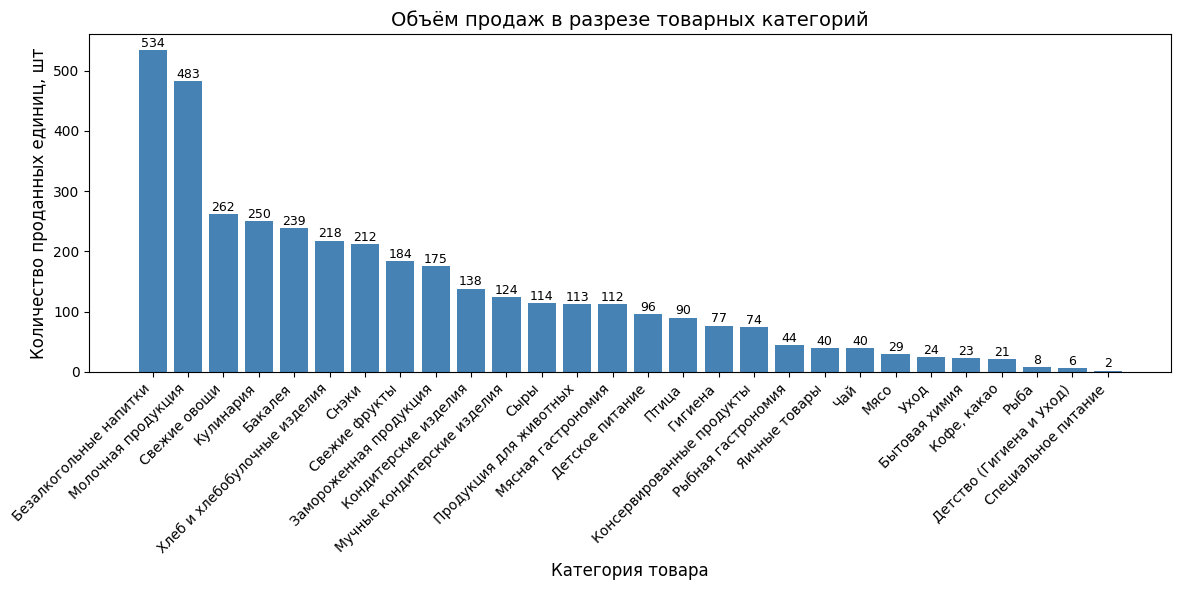

In [101]:
# График
plt.figure(figsize=(12, 6))
bars = plt.bar(category_sales['level1'], category_sales['quantity'], color='steelblue')
plt.xlabel('Категория товара', fontsize=12)
plt.ylabel('Количество проданных единиц, шт', fontsize=12)
plt.title('Объём продаж в разрезе товарных категорий', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

2. Распределение продаж по подкатегориям

In [102]:
# Группировка по level1 и level2
subcat_sales = merged.groupby(['level1', 'level2'], as_index=False)['quantity'].sum()
subcat_sales = subcat_sales.sort_values(['level1', 'quantity'], ascending=[True, False])

In [103]:
# Сводная таблица (категории – строки, подкатегории – столбцы)
pivot_sales = subcat_sales.pivot(index='level1', columns='level2', values='quantity').fillna(0).astype(int)

In [104]:
print("Распределение проданных позиций по категориям и подкатегориям (шт.):")
print(pivot_sales)

Распределение проданных позиций по категориям и подкатегориям (шт.):
level2                        Бананы, косточковые и прочие плоды  \
level1                                                             
Бакалея                                                        0   
Безалкогольные напитки                                         0   
Бытовая химия                                                  0   
Гигиена                                                        0   
Детское питание                                                0   
Детство (Гигиена и Уход)                                       0   
Замороженная продукция                                         0   
Кондитерские изделия                                           0   
Консервированные продукты                                      0   
Кофе, какао                                                    0   
Кулинария                                                      0   
Молочная продукция                             

3. Найти средний чек в заданную дату

In [105]:
# Приводим дату к типу datetime
orders['accepted_at'] = pd.to_datetime(orders['accepted_at'])

In [106]:
# Отбираем заказы за 13 января 2022 года
target = orders[orders['accepted_at'].dt.date == pd.to_datetime('2022-01-13').date()].copy()

In [107]:
# Считаем сумму чека для каждого order_id (price * quantity)
check_sums = target.groupby('order_id').apply(lambda x: (x['price'] * x['quantity']).sum())

C:\Users\рс\AppData\Local\Temp\ipykernel_16560\3389901786.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  check_sums = target.groupby('order_id').apply(lambda x: (x['price'] * x['quantity']).sum())


In [108]:
# Средний чек
avg_check = check_sums.mean()
print(f"Средний чек 13.01.2022: {avg_check:.2f} руб.")

Средний чек 13.01.2022: 915.64 руб.


4. Доля промо в заданной категории

In [109]:
# Объединение таблиц
merged = orders.merge(products, on='product_id', how='left')
# Фильтр по категории "Сыры"
cheese_data = merged[merged['level1'] == 'Сыры'].copy()
# Общее количество проданных единиц в категории "Сыры"
total_units = cheese_data['quantity'].sum()

In [110]:
# Количество единиц, проданных по промо (regular_price != price)
promo_units = cheese_data[cheese_data['regular_price'] != cheese_data['price']]['quantity'].sum()

In [111]:
# Доля промо
if total_units > 0:
    promo_share = promo_units / total_units
    non_promo_share = 1 - promo_share
else:
    promo_share = 0
    non_promo_share = 0

In [112]:
print(f"Категория «Сыры»: всего продано {total_units} шт.")
print(f"Из них по промо: {promo_units} шт. ({promo_share:.1%})")

Категория «Сыры»: всего продано 114 шт.
Из них по промо: 35 шт. (30.7%)


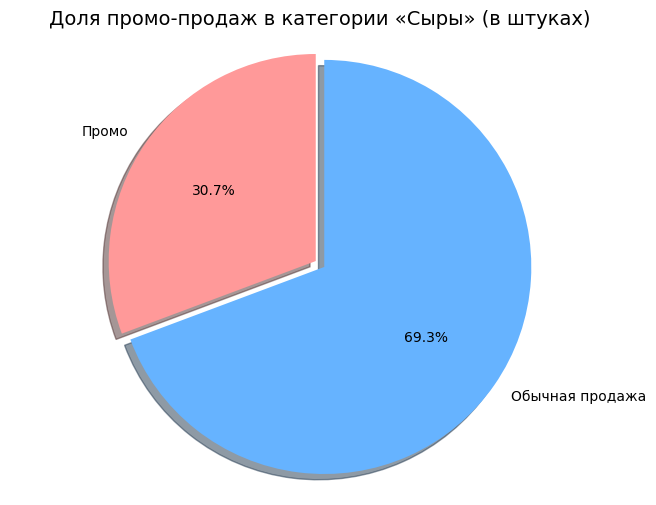

In [113]:
# Данные для графика
labels = ['Промо', 'Обычная продажа']
sizes = [promo_units, total_units - promo_units]
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0)  # чуть выделим промо

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Доля промо-продаж в категории «Сыры» (в штуках)', fontsize=14)
plt.axis('equal')  # круглый пирог
plt.show()

5. Посчитать маржу по категориям

In [114]:
# Объединение
merged = orders.merge(products, on='product_id', how='left')
merged = merged.dropna(subset=['level1', 'cost_price'])

In [115]:
# Объединение
merged = orders.merge(products, on='product_id', how='left')
merged = merged.dropna(subset=['level1', 'cost_price'])

In [116]:
# Создаём вспомогательные колонки
merged['revenue_line'] = merged['price'] * merged['quantity']
merged['margin_rub_line'] = (merged['price'] - merged['cost_price']) * merged['quantity']

In [117]:
# Группировка
category_stats = merged.groupby('level1').agg(
    margin_rub=('margin_rub_line', 'sum'),
    revenue=('revenue_line', 'sum')
).reset_index()

In [118]:
# Расчёт маржи в процентах
category_stats['margin_percent'] = (category_stats['margin_rub'] / category_stats['revenue']) * 100

In [119]:
# Сортировка для горизонтальных графиков
category_stats = category_stats.sort_values('margin_rub', ascending=True)

In [120]:
# Вывод таблицы для проверки
print(category_stats[['level1', 'margin_rub', 'margin_percent']].round(1))

                          level1  margin_rub  margin_percent
22           Специальное питание         208            50.7
5       Детство (Гигиена и Уход)         517            29.9
27                 Яичные товары         781            17.7
17                          Рыба        1021            29.5
24                          Уход        1099            26.3
15        Продукция для животных        1113            26.8
2                  Бытовая химия        1441            26.3
4                Детское питание        1817            35.7
14                          Мясо        2150            26.7
18            Рыбная гастрономия        2765            35.0
26                           Чай        2929            45.7
3                        Гигиена        2971            29.5
8      Консервированные продукты        4154            41.1
9                    Кофе, какао        5059            51.8
16                         Птица        5153            23.1
7           Кондитерские

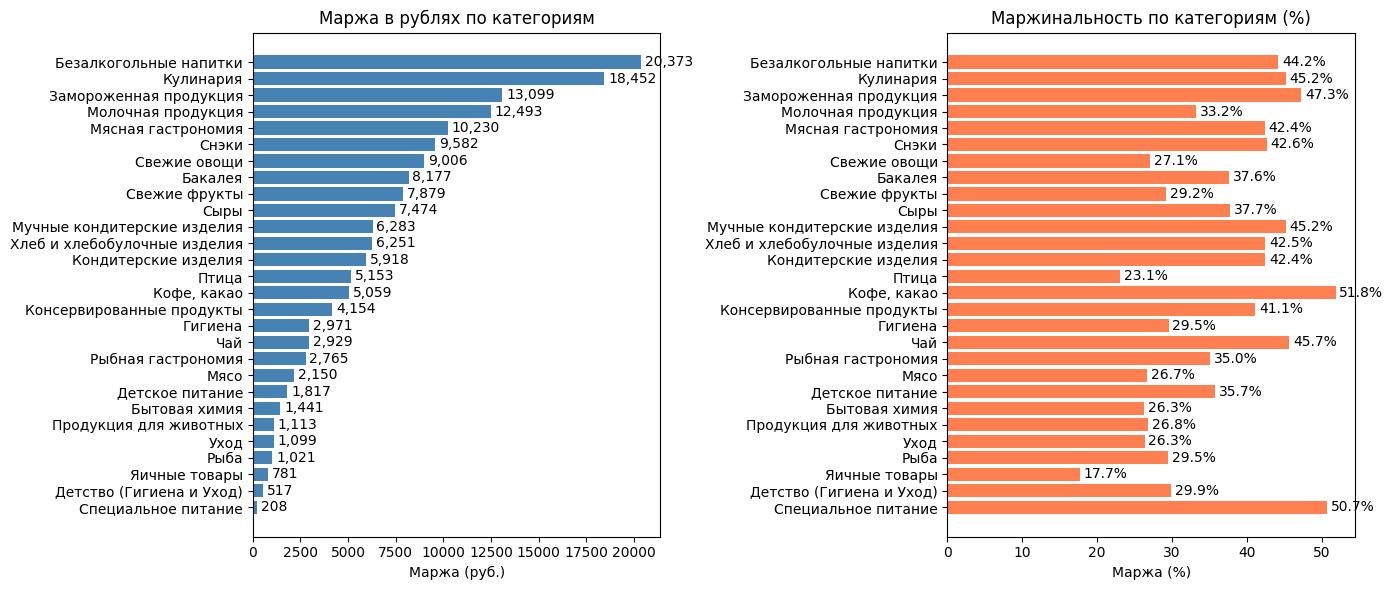

In [121]:


# Построение двух графиков в одной фигуре
plt.figure(figsize=(14, 6))

# Левый график – маржа в рублях
plt.subplot(1, 2, 1)
plt.barh(category_stats['level1'], category_stats['margin_rub'], color='steelblue')
plt.xlabel('Маржа (руб.)')
plt.title('Маржа в рублях по категориям')
for i, v in enumerate(category_stats['margin_rub']):
    plt.text(v + max(category_stats['margin_rub'])*0.01, i, f'{v:,.0f}', va='center')

# Правый график – маржа в процентах
plt.subplot(1, 2, 2)
plt.barh(category_stats['level1'], category_stats['margin_percent'], color='coral')
plt.xlabel('Маржа (%)')
plt.title('Маржинальность по категориям (%)')
for i, v in enumerate(category_stats['margin_percent']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

6. ABC анализ

In [122]:
# Расчёт выручки по каждой строке
merged['revenue'] = merged['price'] * merged['quantity']

In [123]:
# 1. Агрегация по подкатегориям
subcat_stats = merged.groupby('level2').agg(
    quantity=('quantity', 'sum'),
    revenue=('revenue', 'sum')
).reset_index()

In [124]:
# 2. Функция для присвоения ABC-категории
def abc_category(df, metric):
    # Сортировка по убыванию
    df_sorted = df.sort_values(metric, ascending=False).reset_index(drop=True)
    total = df_sorted[metric].sum()
    df_sorted['cum_percent'] = df_sorted[metric].cumsum() / total * 100
    # Присваиваем категории
    df_sorted['abc'] = 'C'  # по умолчанию
    df_sorted.loc[df_sorted['cum_percent'] <= 80, 'abc'] = 'A'
    df_sorted.loc[(df_sorted['cum_percent'] > 80) & (df_sorted['cum_percent'] <= 95), 'abc'] = 'B'
    return df_sorted[['level2', 'abc']]

In [125]:
# Получаем категории по количеству и по выручке
abc_qty = abc_category(subcat_stats.copy(), 'quantity')
abc_rev = abc_category(subcat_stats.copy(), 'revenue')

In [126]:
# Объединяем
result = subcat_stats.merge(abc_qty, on='level2').merge(abc_rev, on='level2', suffixes=('_qty', '_rev'))
result['final_group'] = result['abc_qty'] + ' ' + result['abc_rev']

In [127]:
# Сортируем для наглядности: сначала по количеству (убывание)
result = result.sort_values('quantity', ascending=False)

In [128]:
# Вывод таблицы
print("Результаты ABC-анализа по подкатегориям:")
print(result[['level2', 'quantity', 'revenue', 'abc_qty', 'abc_rev', 'final_group']].to_string(index=False))

Результаты ABC-анализа по подкатегориям:
                               level2  quantity  revenue abc_qty abc_rev final_group
                              Напитки       252    24123       A       A         A A
                        Готовые блюда       248    40356       A       A         A A
         Хлеб и хлебобулочные изделия       218    14724       A       A         A A
                        Снэки соленые       180    17293       A       A         A A
                        Воды питьевые       162     9141       A       A         A A
    Корнеплоды, зелень и прочие овощи       157    14893       A       A         A A
                      Молоко и сливки       147    14902       A       A         A A
           Молочно-десертные продукты       116     5999       A       A         A A
Цитрусовые, семечковые и прочие плоды       108    16818       A       A         A A
  Кисломолочные традиционные продукты       106     8760       A       A         A A
               Тепличные

In [129]:
# Сохраняем результат в Excel (опционально)
result.to_excel('abc_analysis_subcategories.xlsx', index=False)

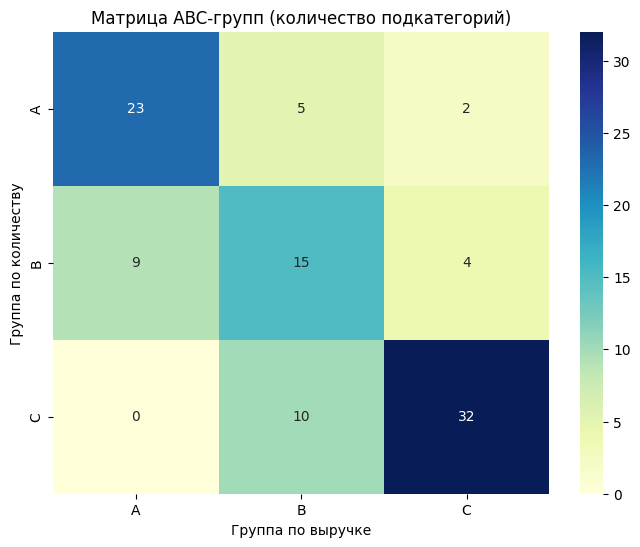

In [130]:
# Сводная таблица: количество подкатегорий в каждой итоговой группе
pivot_groups = result.groupby(['abc_qty', 'abc_rev']).size().unstack(fill_value=0)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_groups, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Матрица ABC-групп (количество подкатегорий)')
plt.xlabel('Группа по выручке')
plt.ylabel('Группа по количеству')
plt.show()